In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import geopandas as gpd

/Users/huanglinchun/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Rule of thumb

For <font color='yellow'> Road Data </font>: Use `processed/road_data_adj_count_usage.parquet`

For <font color='skyblue'> Adjacency Matrix </font>: Use `processed/adjacency_demand_buffered.parquet`

## Road Data

Load the data: use `gpd.read_parquet()`

Data Schema:

- `roadID`             : i, road id in order
  
- `roadID_foreign`     : road id from original raw file. 
  
- `roadName`          : road name
  
- `geometry`           : geometry column for this gdf (in shapely.geometrhPolygon often)
  
- `centroid`           : the center of the road (shapely.geometry.Point)
  
- `roadDemand`         : demand of road i, calculated by the centroid
  
- `roadDemand_m2` : demand of road i, calculated by averaging the demand of several points on the road
  
- `width`    : road width
  
- `length`   : road length (meters)

- `length_norm` : normalized road length. constant 3 is added to ensure positive value
  
- `danger`   : degree of danger of road i, calculated by the centroid
 
- `danger_m2`: danger of road i, calculated by averaging the demand of several points on the road
  
- `roadDemand_m2_norm` : normalized roadDemand_m2, constant 3 is added to ensure positive value
  
- `danger_m2_norm`: normalized danger_m2, constant 3 is added to ensure positive value

- `adj_count`: number of adjacent roads

- `has_bike_lane`: whether a bike lane is built on road i


We define the utility of road i ($U_i^{road}$ in obj. function) as the Cobb Douglas function of road length and road demand:

$$U_i^{\text{road}} = (L_i^{\text{norm}})^\alpha (D_i^{norm}) ^{1-\alpha}$$

where $L_i^{norm}$ is the normalized length, and $D^{norm}_i$ is the normalized demand. Parameter $\alpha$ is the relative importance of road length.

In [2]:
gdf_road = gpd.read_parquet("./processed/road_data_adj_count_usage.parquet")
gdf_road.head(2)

,roadID,roadID_foreign,roadName,geometry,centroid,roadDemand,roadDemand_m2,width,length,danger,danger_m2,roadDemand_m2_norm,danger_m2_norm,length_norm,adj_count,has_bike_lane
0,1,南深路-31,南深路,"POLYGON ((121.62348 25.0182, 121.6234 25.01805...",POINT (121.6231981462958 25.017423573687317),2473.216309,2548.270996,17.5733,185.594,1,1,1.698854,2.381649,5.280953,1,0
1,2,南深路-30,南深路,"POLYGON ((121.62292 25.01926, 121.62296 25.019...",POINT (121.62320858388321 25.018891469451464),2626.366699,2626.366699,14.5230,175.571,1,1,1.703831,2.381649,5.071632,2,0


Some variations:

1. `./processed/road_data.parquet`: first version of road data.
2. `./processed/road_data_adj_count.parquet`: road data with a new column "adj_count", which describes the number of adjacent roads to road i.
3. `./processed/road_data_adj_count_buffered.parquet`: simliar to 2, but the number of adjacent roads is calculated based on the "buffered" adjacency matrix (will be explained in the next paragraph).
4. `./processed/road_data_adj_count_usage.parquet`: similar to 3, but with an additional column describing whether a bike lane has been built on road i. This would be used as the official version.

## Adjacency Matrix

Load the data: use `gpd.read_parquet()`

\# Note that this file only contant adjacent road pairs! Road pair that is not adjacent is not contained.

data schema:

- `road_i`: index of road i, could be referred to the `roadID` column in road_data.parquet
  
- `road_j`: index of road j, could be referred to the `roadID` column in road_data.parquet
  
- `intersection_geom`: the geometry of the intersection of road i and j.
  
- `intersection_demand`: the demand of the intersection. For more details for calculation, please refer to `roadProcessing/computeAdjacency.py`
  
- `intersection_demand_norm`: normalized intersection demand, added by constant 3 to ensure positive value

Example data looks like this:

In [3]:
gpd.read_parquet("./processed/adjacency_demand_buffered.parquet").head(5)

,road_i,road_j,intersection_geom,intersection_demand,intersection_demand_norm
0,1,2,"POLYGON ((121.62218 25.01819, 121.62238 25.018...",2548.270996,1.630450
1,1,3,"POLYGON ((121.62218 25.01819, 121.62238 25.018...",2626.366699,1.635713
2,2,3,"POLYGON ((121.62231 25.02014, 121.6224 25.0201...",2730.639404,1.642740
3,2,4,"POLYGON ((121.62231 25.02014, 121.6224 25.0201...",2815.946289,1.648490
4,3,4,"POLYGON ((121.62105 25.02003, 121.62106 25.020...",2815.946289,1.648490


Because the number of road and road pairs is too large for the optimizer to run, we want to limit the number of candidate roads by filtering out roads without any adjacent roads. However, during our analysis, we found that some roads are considered to have "no adjacent road" while seem to be adjacent to other roads (at least for the start and the end) on the map (See the following picture).

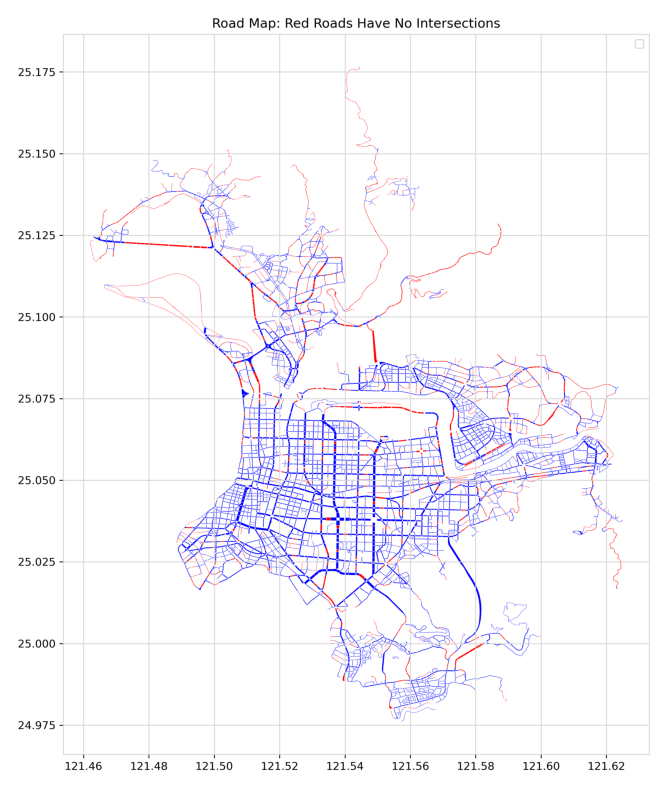

In [4]:
img = mpimg.imread("../roadProcessing/output/road_map_red_no_intersection.png")  # Load PNG
fig, ax = plt.subplots(1, 1, figsize = (10, 10))
ax.imshow(img)
ax.axis("off")  # optional: hide axes
plt.show()

Therefore, we also try to "buffer" the geometry of each road during the evaluation of adjacency (see `roadProcessing/computeAdjacency.py`).

In [5]:
adj_gdf_before   = gpd.read_parquet("../data/processed/adjacency_demand.parquet")
adj_gdf_buffered = gpd.read_parquet("../data/processed/adjacency_demand_buffered.parquet")

print(f"""Number of adjacent road pairs before buffering: {len(adj_gdf_before)};
Number of adjacent road pairs after buffering: {len(adj_gdf_buffered)}.""")

Number of adjacent road pairs before buffering: 6406;
Number of adjacent road pairs after buffering: 36590.


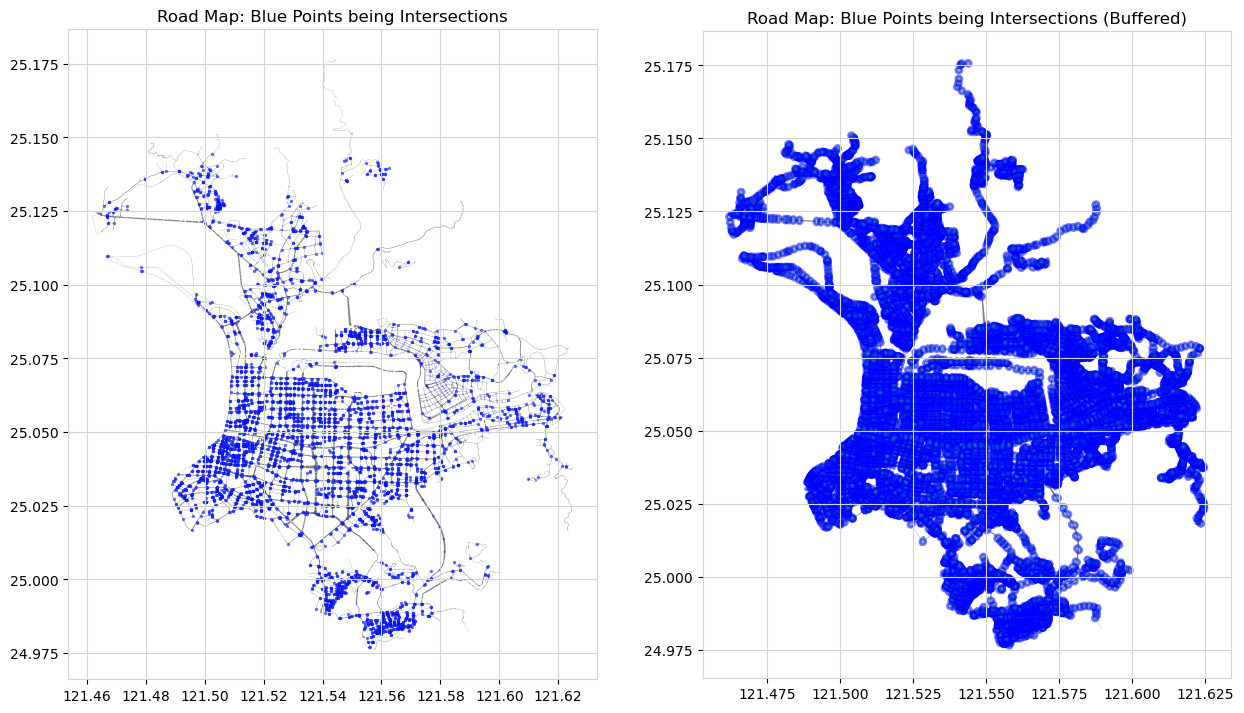

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 10))

gdf_road.plot(ax = ax1, color = "gray", linewidth = 2.5)
adj_gdf_before.plot(ax = ax1, edgecolor="blue", alpha=0.5, markersize=2)
gdf_road.plot(ax = ax2, color = "gray", linewidth = 2.5)
adj_gdf_buffered.plot(ax = ax2, edgecolor="blue", alpha=0.5, linewidth = 2)

ax1.set_title("Road Map: Blue Points being Intersections")
ax2.set_title("Road Map: Blue Points being Intersections (Buffered)")
ax1.grid(True, color='lightgray')
ax2.grid(True, color='lightgray')

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_color('lightgray')
    ax.set_aspect('equal')

plt.show()

The result map of roads without intersections are shown in the following. The mentioned problem is alleviated.

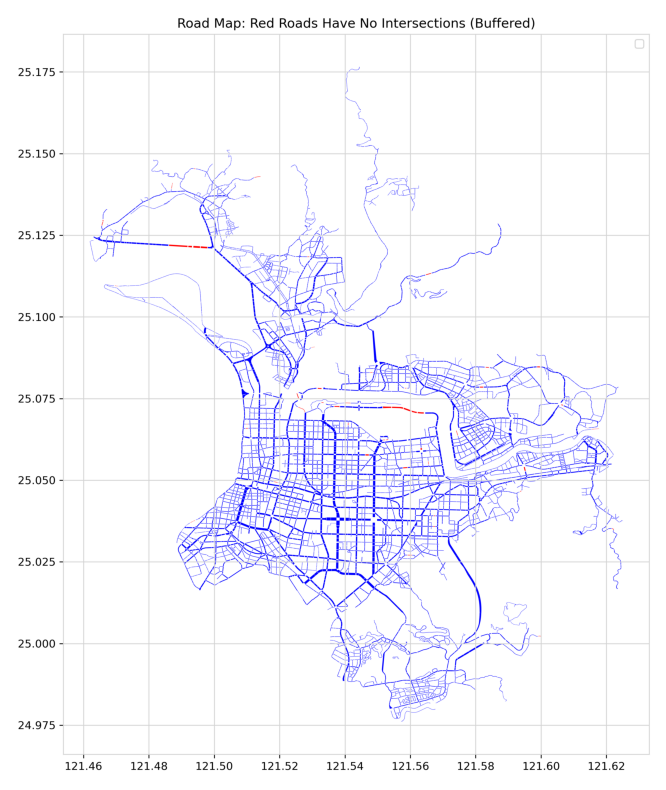

In [7]:
img = mpimg.imread("../roadProcessing/output/road_map_red_no_intersection_buffered.png")  # Load PNG
fig, ax = plt.subplots(1, 1, figsize = (10, 10))
ax.imshow(img)
ax.axis("off")  # optional: hide axes
plt.show()

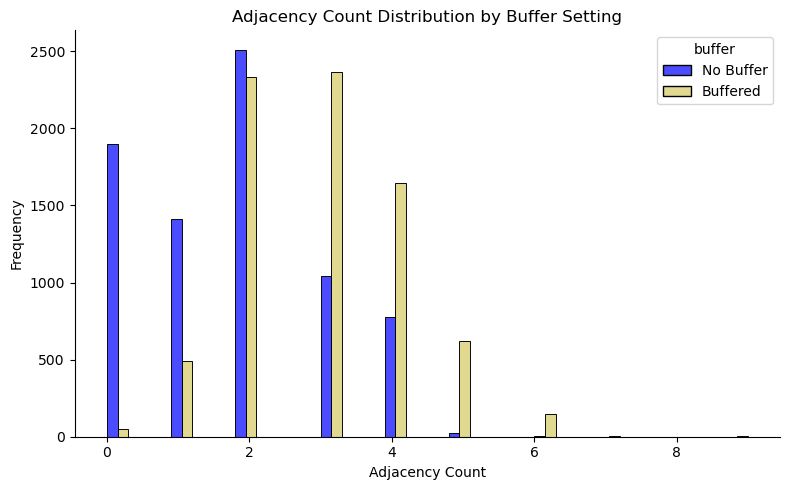

In [8]:
road_adj_gdf_before   = gpd.read_parquet("../data/processed/road_data_adj_count.parquet")
road_adj_gdf_buffered = gpd.read_parquet("../data/processed/road_data_adj_count_buffered.parquet")
import seaborn as sns
import pandas as pd

road_adj_gdf_before['buffer'] = 'No Buffer'
road_adj_gdf_buffered['buffer'] = 'Buffered'
combined = pd.concat([road_adj_gdf_before, road_adj_gdf_buffered])

plt.figure(figsize=(8, 5))
ax = sns.histplot(
    data=combined,
    x='adj_count',
    hue='buffer',
    bins=30,
    multiple='dodge',  # 關鍵參數：並列而不是疊加
    palette=['blue', '#d7c963'],
    alpha=0.7
)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.set_title("Adjacency Count Distribution by Buffer Setting")
ax.set_xlabel("Adjacency Count")
ax.set_ylabel("Frequency")


plt.tight_layout()
plt.show()


## MRT station data 

This data is for the constraint **C2** (Area Coverage Constraint). Use MRT station as the proxy of important facilities.

data schema (important columns only):

- `geometry`: geometry column for the station (in lat, lon coordinate)
  
- `x_m`: the x coordinate, transformed from lat, lon (so as to calculate Euclidean distance with road)
  
- `y_m`: the y coordinate, transformed from lat, lon (so as to calculate Euclidean distance with road)


In [9]:
gpd.read_parquet("./processed/mrt_stations.parquet").head(5)

,wkt_geom,MARKID,MARKTYPE1,MARKTYPE2,MARKNAME1,MARKNAME2,異動日期_西元年月,ADDRESS,TEL,坐標系統,geometry,x_m,y_m
219,Point (304292.58899999968707561 2761254.992000...,F0000003261,9960103,NaN,臺北捷運新店站_G01,北捷新店站_G01,201904,新北市新店區北宜路一段2號,02-218-12345,TM2,POINT (121.53768 24.9582),-2702.031253,-8784.257307
220,Point (304297.5849999999627471 2761256.4240000...,F0000003151,9960103,NaN,臺北捷運新店站-出入口,北捷新店站-出入口,201904,新北市新店區北新路一段與北宜路一段交叉口,None,TM2,POINT (121.53773 24.95821),-2697.029023,-8782.846000
221,Point (292262.35800000000745058 2761299.676000...,F0000010541,9960103,NaN,臺北捷運頂埔站-出入口2,北捷頂埔站-出入口2,202201,新北市土城區中央路四段，近鴻海精密工業,None,TM2,POINT (121.41855 24.95898),-14732.831395,-8689.542676
222,Point (292262.8880000002682209 2761319.2390000...,F0000000573,9960103,NaN,臺北捷運頂埔站_BL01,北捷頂埔站_BL01,201906,新北市土城區中央路四段51之6號B3,02-218-12345,TM2,POINT (121.41855 24.95916),-14732.220008,-8669.980507
223,Point (292241.46999999973922968 2761339.161000...,F0000009516,9960103,NaN,臺北捷運頂埔站-出入口1,北捷頂埔站-出入口1,202201,新北市土城區中央路四段約100號旁,None,TM2,POINT (121.41834 24.95934),-14753.556655,-8649.968021


## Notes on Danger Modeling

Same calculation method as Jori did for demand modeling.

First, generate several grids to the map. Then for each grid, calculate the frequency of car accidents (2024) in Taipei as the proxy of danger.

Finally, for each road segment, we pick several points and get their corresponding danger level by querying "which grid is this point in", and then average these danger as the danger (risk) of road.

Please refer to the following map.

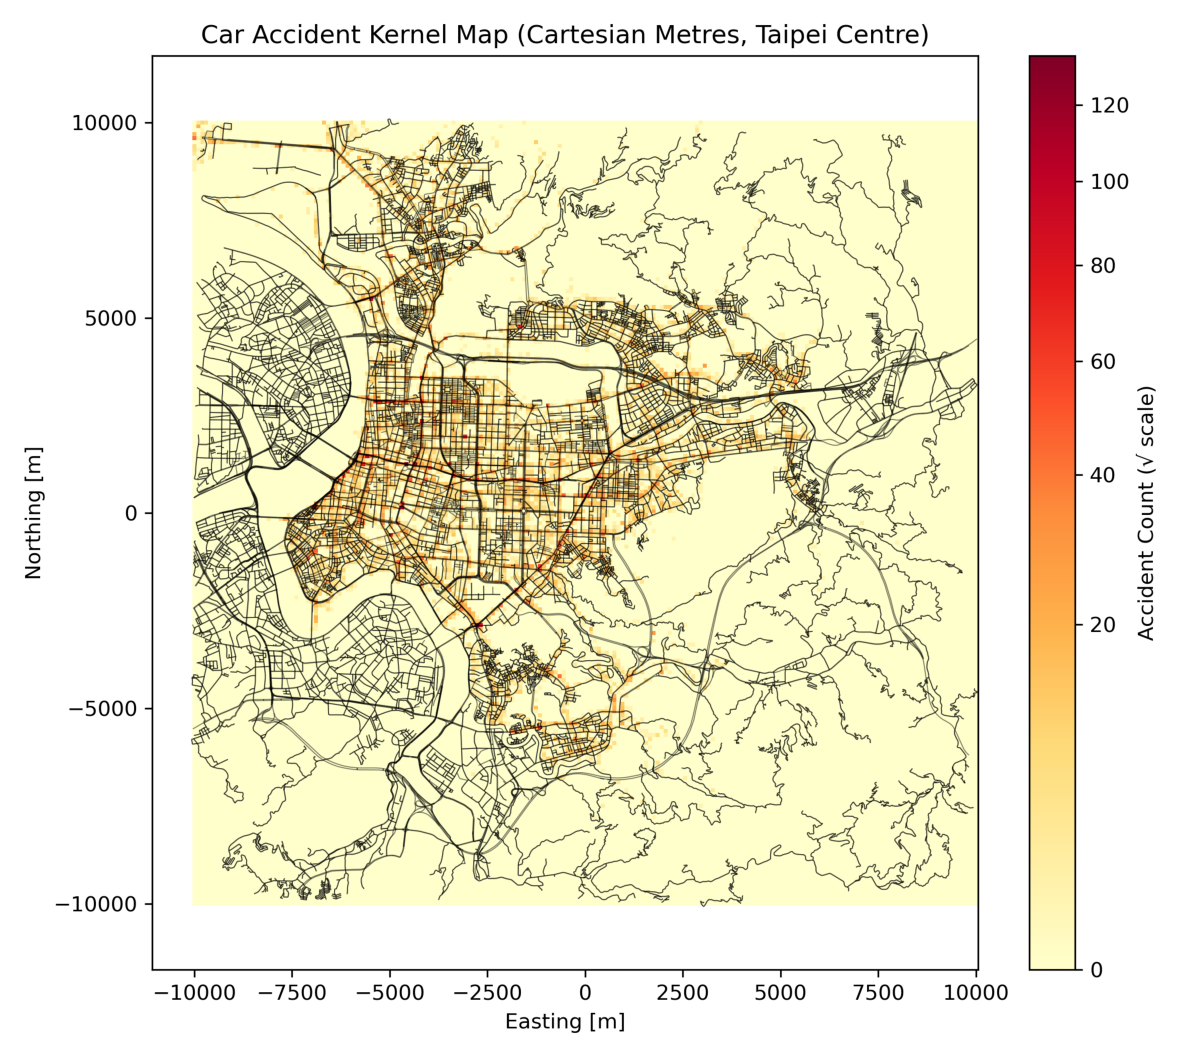

In [10]:
img = mpimg.imread("../roadProcessing/output/car_accident_heatmap.png")  # Load PNG
fig, ax = plt.subplots(1, 1, figsize = (15, 15))
ax.imshow(img)
ax.axis("off")  # optional: hide axes
plt.show()